In [ ]:

# CardioGuard --- Risk Segmentation

# Purpose:
# Group participants into meaningful cardiometabolic risk clusters.
# This helps identify prevention groups such as:
# - Low-risk healthy profile
# - Lifestyle-risk profile
# - Metabolic-risk profile
# - High-risk clinical profile

In [42]:
# Setup & import libraries

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline

sns.set_theme(style="whitegrid", font_scale=1.2)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


DATA_RAW = os.path.join("..", "data", "raw")
DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")

os.makedirs(MODEL_DIR, exist_ok=True)

In [43]:
# Load data

features = pd.read_csv(
    os.path.join(DATA_PROCESSED, "cardioguard_features.csv")
)

### Step 1 - Select Clustering Features

In [44]:
# We choose features that represent the main cardiometabolic risk domains:

# Anthropometric risk
# Cardiovascular risk
# Glycemic risk
# Lipid risk
# Lifestyle risk
# Socioeconomic vulnerability


CLUSTER_COLS = [

    # Anthropometric features
    "bmi",
    "waist_circumference",
    "waist_to_height_ratio",

    # Cardiovascular features
    "systolic_bp",
    "diastolic_bp",
    "pulse_pressure",
    "mean_arterial_pressure",

    # Glycemic features
    "fasting_glucose",
    "hba1c",
    "glycemic_burden_score",

    # Lipid features
    "total_cholesterol",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides",
    "tc_hdl_ratio",
    "trig_hdl_ratio",

    # Lifestyle features
    "smoker_flag",
    "inactive_flag",
    "lifestyle_risk_score",

    # Social / demographic risk
    "age",
    "poverty_income_ratio",
    "social_vulnerability_score"
]

In [45]:
# KMeans cannot handle missing values, so drop rows with missing clustering features

seg_df = features[
    ["participant_id", "risk_segment", "high_risk_flag"] + CLUSTER_COLS
].dropna().copy()

print(f"Participants for segmentation: {len(seg_df):,}")

Participants for segmentation: 1,665


### Step 2 - Scaling

In [46]:
# KMeans uses distance calculations.

# If we do not scale, variables with large values such as cholesterol or glucose can dominate smaller variables such as risk scores.

# Scaling converts every feature to:

# mean = 0
# standard deviation = 1
scaler = StandardScaler()

X = scaler.fit_transform(
    seg_df[CLUSTER_COLS]
)

### Step 3 - Elbow and Silhouette Test

In [47]:
# We test different values of k to decide how many risk groups to create.

inertias = []
silhouettes = []

K_RANGE = range(2, 9)

for k in K_RANGE:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X)

    inertias.append(km.inertia_)

    silhouettes.append(
        silhouette_score(
            X,
            labels,
            sample_size=min(3000, len(seg_df)),
            random_state=42
        )
    )


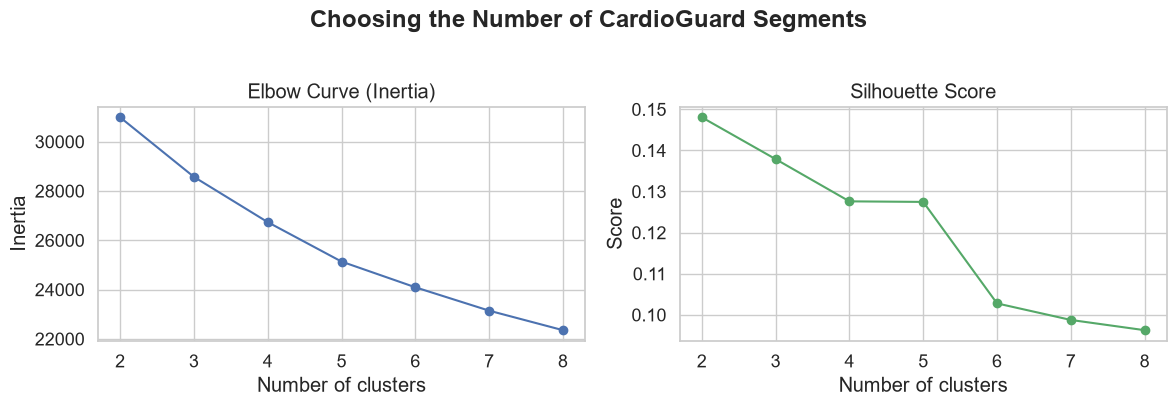

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_RANGE), inertias, "bo-")
axes[0].set(
    title="Elbow Curve (Inertia)",
    xlabel="Number of clusters",
    ylabel="Inertia"
)

axes[1].plot(list(K_RANGE), silhouettes, "go-")
axes[1].set(
    title="Silhouette Score",
    xlabel="Number of clusters",
    ylabel="Score"
)

plt.suptitle(
    "Choosing the Number of CardioGuard Segments",
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### Step 4 - Fit Final KMeans Model


In [49]:
# start with k = 4,

# Low Risk
# Lifestyle Risk
# Metabolic Risk
# High Clinical Risk

K_FINAL = 4

kmeans = KMeans(
    n_clusters=K_FINAL,
    random_state=42,
    n_init=10
)

seg_df["cluster"] = kmeans.fit_predict(X)

final_silhouette = silhouette_score(
    X,
    seg_df["cluster"],
    sample_size=min(3000, len(seg_df)),
    random_state=42
)

print(
    f"k={K_FINAL} | Inertia: {kmeans.inertia_:,.0f} | "
    f"Silhouette: {final_silhouette:.2f}"
)

print(seg_df["cluster"].value_counts().sort_index())

k=4 | Inertia: 26,733 | Silhouette: 0.13
cluster
0    362
1    388
2    640
3    275
Name: count, dtype: int64


### Step 5 - Cluster Profiling

In [50]:
# Now we check the average clinical profile of each cluster.

profile_cols = [

    "age",
    "bmi",
    "waist_circumference",

    "systolic_bp",
    "diastolic_bp",

    "fasting_glucose",
    "hba1c",

    "total_cholesterol",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides",

    "smoker_flag",
    "inactive_flag",

    "glycemic_burden_score",
    "lifestyle_risk_score",
    "social_vulnerability_score"
]

profile = (
    seg_df
    .groupby("cluster")[profile_cols]
    .mean()
    .round(2)
)

print(profile.T.to_string())

cluster                          0       1       2       3
age                          48.04   65.25   37.19   56.95
bmi                          30.69   27.51   26.55   38.66
waist_circumference         104.00   97.70   90.26  122.50
systolic_bp                 124.88  143.92  111.69  129.02
diastolic_bp                 76.39   76.31   67.36   70.02
fasting_glucose             110.60  110.37   98.55  155.52
hba1c                         5.72    5.85    5.34    7.05
total_cholesterol           220.52  188.00  173.35  165.81
hdl_cholesterol              43.23   60.10   58.76   45.29
ldl_cholesterol             141.47  110.11  100.58   95.62
triglycerides               179.07   88.86   70.01  124.57
smoker_flag                   0.45    0.52    0.29    0.60
inactive_flag                 0.55    0.64    0.31    0.65
glycemic_burden_score         1.23    1.34    0.59    1.75
lifestyle_risk_score          1.00    1.16    0.60    1.25
social_vulnerability_score    0.46    1.04    0.30    0.

### Step 6 - Heatmap of Cluster Profiles

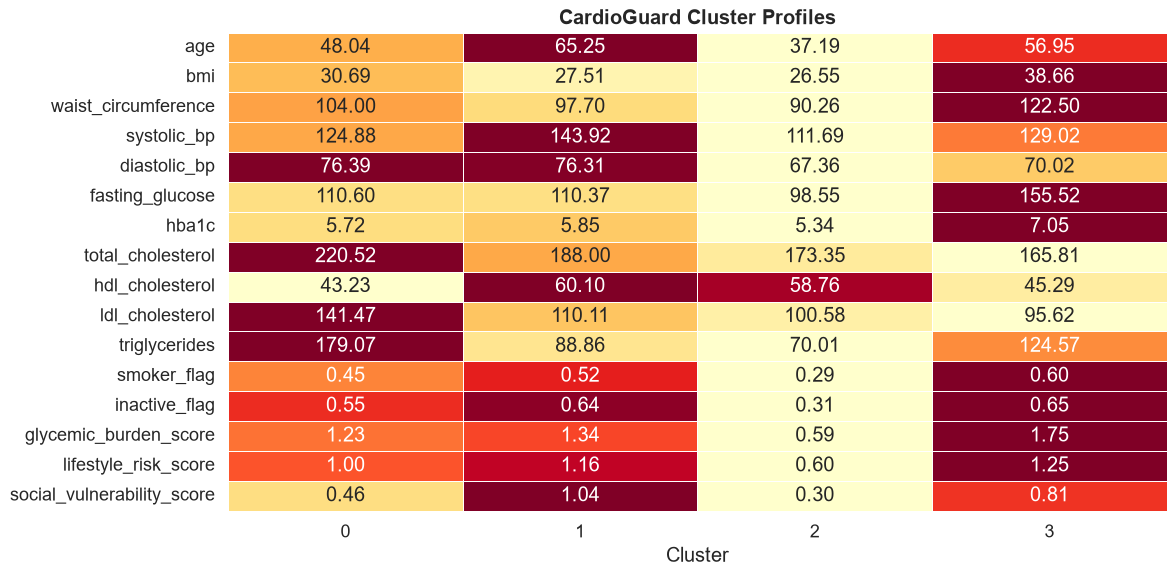

In [51]:

# The colour is normalized, but the numbers shown are the real average values.

profile_norm = (
    profile - profile.min()
) / (
    profile.max() - profile.min() + 1e-9
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    profile_norm.T,
    annot=profile.T,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar=False
)

ax.set_title(
    "CardioGuard Cluster Profiles",
    fontweight="bold"
)

ax.set_xlabel("Cluster")

plt.tight_layout()
plt.show()

### Step 7 - Assign Clinical Segment Labels

In [52]:
# We label clusters based on their average risk burden.

# The cluster with the highest average clinical risk becomes the highest-risk segment.

risk_profile_cols = [
    "bmi",
    "systolic_bp",
    "fasting_glucose",
    "hba1c",
    "triglycerides",
    "glycemic_burden_score",
    "lifestyle_risk_score",
    "social_vulnerability_score"
]

cluster_risk_score = (
    seg_df
    .groupby("cluster")[risk_profile_cols]
    .mean()
    .mean(axis=1)
)

rank = cluster_risk_score.rank(
    ascending=False
).astype(int)

SEGMENT_LABELS = {}

names = [
    "High Clinical Risk",
    "Metabolic Risk",
    "Lifestyle Risk",
    "Lower Risk"
]

for cluster_id, r in rank.items():
    SEGMENT_LABELS[cluster_id] = names[r - 1]

seg_df["cardioguard_segment"] = seg_df["cluster"].map(SEGMENT_LABELS)

print(seg_df["cardioguard_segment"].value_counts())

cardioguard_segment
Lower Risk            640
Lifestyle Risk        388
Metabolic Risk        362
High Clinical Risk    275
Name: count, dtype: int64


### Step 8 - Segment vs High Risk Overlap

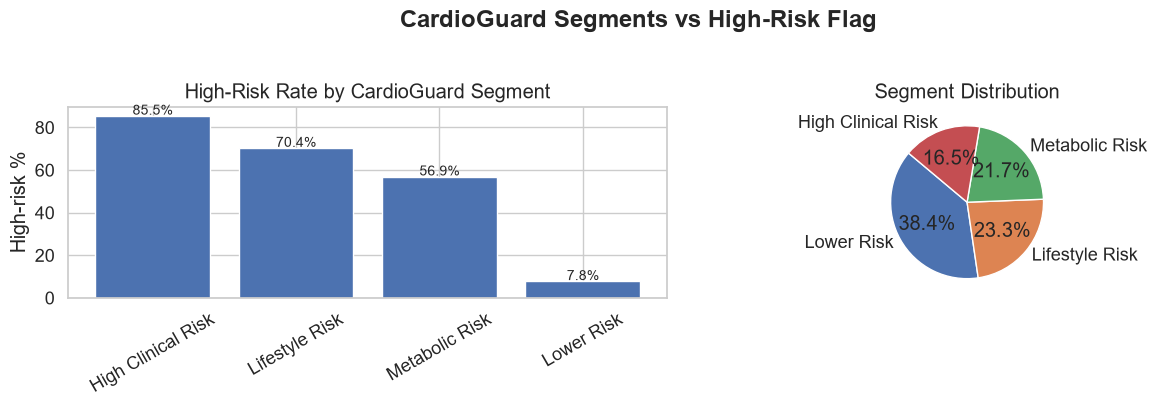

In [53]:

# Now we check whether the unsupervised segments align with the engineered high-risk flag.

# If the segmentation is useful, high-risk segments should have a higher percentage of high_risk_flag = 1.

risk_by_segment = (
    seg_df
    .groupby("cardioguard_segment")["high_risk_flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

segment_count = seg_df["cardioguard_segment"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
bars = axes[0].bar(
    risk_by_segment.index,
    risk_by_segment.values,
    edgecolor="white"
)

for bar, value in zip(bars, risk_by_segment.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

axes[0].set(
    title="High-Risk Rate by CardioGuard Segment",
    ylabel="High-risk %"
)

axes[0].tick_params(axis="x", rotation=30)

# Pie chart
axes[1].pie(
    segment_count.values,
    labels=segment_count.index,
    autopct="%1.1f%%",
    startangle=140
)

axes[1].set_title("Segment Distribution")

plt.suptitle(
    "CardioGuard Segments vs High-Risk Flag",
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### Step 9 - Business / Public Health Interpretation

In [54]:

segment_summary = (
    seg_df
    .groupby("cardioguard_segment")
    .agg(
        participants=("participant_id", "count"),
        high_risk_rate=("high_risk_flag", "mean"),
        avg_age=("age", "mean"),
        avg_bmi=("bmi", "mean"),
        avg_systolic_bp=("systolic_bp", "mean"),
        avg_glucose=("fasting_glucose", "mean"),
        avg_hba1c=("hba1c", "mean"),
        avg_triglycerides=("triglycerides", "mean"),
        smoker_rate=("smoker_flag", "mean"),
        inactive_rate=("inactive_flag", "mean")
    )
    .round(2)
)

segment_summary["high_risk_rate"] = (
    segment_summary["high_risk_rate"] * 100
).round(1)

segment_summary["smoker_rate"] = (
    segment_summary["smoker_rate"] * 100
).round(1)

segment_summary["inactive_rate"] = (
    segment_summary["inactive_rate"] * 100
).round(1)

segment_summary

,participants,high_risk_rate,avg_age,avg_bmi,avg_systolic_bp,avg_glucose,avg_hba1c,avg_triglycerides,smoker_rate,inactive_rate
cardioguard_segment,,,,,,,,,,
High Clinical Risk,275,85.0,56.95,38.66,129.02,155.52,7.05,124.57,60.0,65.0
Lifestyle Risk,388,70.0,65.25,27.51,143.92,110.37,5.85,88.86,52.0,64.0
Lower Risk,640,8.0,37.19,26.55,111.69,98.55,5.34,70.01,29.0,31.0
Metabolic Risk,362,57.0,48.04,30.69,124.88,110.60,5.72,179.07,45.0,55.0


In [58]:

# nterpretation guide
# Lower Risk:
# Participants with relatively healthier cardiometabolic profiles.
# Public health action: maintain prevention, lifestyle education, annual screening.

# Lifestyle Risk:
# Participants whose main risk is smoking, inactivity, or social vulnerability.
# Public health action: smoking cessation, exercise referral, community prevention.

# Metabolic Risk:
# Participants with obesity, abnormal glucose, dyslipidemia, or early metabolic burden.
# Public health action: diabetes prevention, weight management, dietetic support.

# High Clinical Risk:
# Participants with multiple elevated clinical markers.
# Public health action: urgent risk review, GP follow-up, cardiovascular prevention pathway.

### Step 10 - Save Segment Assignments and Model Artifacts

In [56]:
assignments = seg_df[
    [
        "participant_id",
        "cluster",
        "cardioguard_segment"
    ]
]

assignments.to_csv(
    os.path.join(DATA_PROCESSED, "cardioguard_segment_assignment.csv"),
    index=False
)

print("cardioguard_segment_assignment.csv saved successfully")
joblib.dump(
    kmeans,
    os.path.join(MODEL_DIR, "cardioguard_kmeans_segmentation.pkl")
)

joblib.dump(
    scaler,
    os.path.join(MODEL_DIR, "cardioguard_scaler_segmentation.pkl")
)

joblib.dump(
    CLUSTER_COLS,
    os.path.join(MODEL_DIR, "cardioguard_segmentation_feature_cols.pkl")
)

cardioguard_segment_assignment.csv saved successfully


['..\\models\\cardioguard_segmentation_feature_cols.pkl']